Owner: Maleesha  
Project: Explainable-Fashion-Design-AI  
Module: CCS4310 – Deep Learning  
Stage: Preprocessing  
Purpose: Create validated deterministic manifests and transforms.

# DeepFashion generation preprocessing





## Configuration

In [1]:
from pathlib import Path
import pathlib
import json,random,hashlib
import numpy as np,pandas as pd
from PIL import Image
from tqdm.auto import tqdm
PROJECT_ROOT=Path.cwd()
for candidate in [PROJECT_ROOT,*PROJECT_ROOT.parents]:
    if (candidate/"data"/"raw"/"deepfashion").exists(): PROJECT_ROOT=candidate; break
DEEPFASHION_DIR=PROJECT_ROOT/"data"/"raw"/"deepfashion"; IMAGES_DIR=DEEPFASHION_DIR/"images"
CAPTIONS_PATH=DEEPFASHION_DIR/"captions.json" # define before any use
INTERIM_DIR=PROJECT_ROOT/"data"/"interim"; MANIFEST_PATH=INTERIM_DIR/"deepfashion_generation_manifest.csv"
TRAIN_CSV_PATH=INTERIM_DIR/"deepfashion_generation_train.csv"; VALIDATION_CSV_PATH=INTERIM_DIR/"deepfashion_generation_validation.csv"
SUMMARY_JSON_PATH=INTERIM_DIR/"deepfashion_generation_preprocessing_summary.json"
SEED=42; random_state=SEED; FAST_DEV_RUN=True; MAX=1000; FAST_DEV_MAX_SAMPLES=MAX; MAX_SAMPLES=MAX if FAST_DEV_RUN else None; VALIDATION_FRACTION=.10
IMAGE_EXTENSIONS={".jpg",".jpeg",".png",".webp"}; random.seed(SEED); np.random.seed(SEED)



## Robust parser and identifier matching derived from actual structure

In [2]:
def _caption_text(value):
    if isinstance(value, str): return value.strip()
    if isinstance(value, (list, tuple)): return " ".join(filter(None, (_caption_text(x) for x in value))).strip()
    if isinstance(value, dict):
        for key in ("text", "caption", "description", "sentence", "prompt"):
            if key in value:
                text = _caption_text(value[key])
                if text: return text
    return ""

_ID_KEYS=("image", "image_path", "image_name", "filename", "file_name", "file", "path", "id", "image_id", "name")
_TEXT_KEYS=("caption", "captions", "text", "description", "sentence", "prompt")
def _normal_key(value):
    return str(value).replace("\\", "/").lstrip("./")
def _walk_caption_objects(obj, context=""):
    """Yield only evidence-backed (identifier, caption) pairs from common JSON layouts."""
    if isinstance(obj, dict):
        identifier = next((obj[k] for k in _ID_KEYS if k in obj and isinstance(obj[k], (str, int))), None)
        text = next((_caption_text(obj[k]) for k in _TEXT_KEYS if k in obj), "")
        if identifier is not None and text: yield _normal_key(identifier), text
        # Mapping layout: {filename: caption/list/object}.
        for key, value in obj.items():
            key_text = str(key)
            value_text = _caption_text(value)
            looks_like_id = pathlib.PurePosixPath(key_text.replace("\\", "/")).suffix.lower() in IMAGE_EXTENSIONS or "/" in key_text or "\\" in key_text
            if (value_text or looks_like_id) and (looks_like_id or context == ""):
                yield _normal_key(key_text), value_text
            elif isinstance(value, (dict, list)):
                yield from _walk_caption_objects(value, key_text)
    elif isinstance(obj, list):
        for value in obj: yield from _walk_caption_objects(value, context)

def normalize_captions(raw):
    records={}
    for identifier, caption in _walk_caption_objects(raw):
        records.setdefault(_normal_key(identifier), caption)
    return records

def caption_for_path(path, records):
    path=path if isinstance(path, pathlib.PurePosixPath) else pathlib.PurePosixPath(str(path).replace("\\", "/"))
    candidates={path.as_posix(), path.name, path.stem}
    exact=[(k,v) for k,v in records.items() if k in candidates]
    if exact: return exact[0][1]
    basename=[(k,v) for k,v in records.items() if pathlib.PurePosixPath(k).name == path.name]
    if len(basename)==1: return basename[0][1]
    stem=[(k,v) for k,v in records.items() if pathlib.PurePosixPath(k).stem == path.stem]
    return stem[0][1] if len(stem)==1 else ""


   

## Independent validation and exact manifests

In [3]:
assert CAPTIONS_PATH.exists(), CAPTIONS_PATH
raw=json.loads(CAPTIONS_PATH.read_text(encoding="utf-8")); raw_caption_pairs=list(_walk_caption_objects(raw)); records=normalize_captions(raw); duplicate_caption_records=max(0,len(raw_caption_pairs)-len(records))
all_paths=sorted(p for p in IMAGES_DIR.rglob("*") if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS)
paths=random.Random(SEED).sample(all_paths,min(MAX_SAMPLES,len(all_paths))) if MAX_SAMPLES else all_paths
all_image_names={p.name for p in all_paths}; sample_image_names={p.name for p in paths}
full_dataset_unmatched_caption_records=sum(pathlib.PurePosixPath(str(identifier)).name not in all_image_names for identifier in records)
sample_records_selected_for_processing=len(paths)
sample_images_without_caption=sum(not caption_for_path(p.relative_to(IMAGES_DIR),records) for p in paths)
full_dataset_empty=sum(pathlib.PurePosixPath(str(identifier)).name in all_image_names and not caption for identifier,caption in records.items())
empty_caption_in_sample=sum(pathlib.PurePosixPath(str(identifier)).name in sample_image_names and not caption for identifier,caption in records.items())
rows=[]; corrupt=[]
for p in tqdm(paths,desc="Validating images"):
    try:
        with Image.open(p) as im:
            rel=p.relative_to(IMAGES_DIR).as_posix(); cap=caption_for_path(p.relative_to(IMAGES_DIR),records)
            if not cap:
                continue
            rows.append({"image_path":p.relative_to(IMAGES_DIR).as_posix(),"caption":cap,"width":im.width,"height":im.height,"mode":im.mode,"aspect_ratio":im.width/im.height})
    except Exception as exc: corrupt.append({"image_path":p.relative_to(IMAGES_DIR).as_posix(),"error":str(exc)})
raw_manifest=pd.DataFrame(rows)
duplicate_records_removed=int(raw_manifest.duplicated("image_path",keep="first").sum()) if not raw_manifest.empty else 0
manifest=raw_manifest.drop_duplicates("image_path",keep="first").sort_values("image_path").reset_index(drop=True)
assert not manifest.empty, "No valid captioned images found"
manifest["caption_hash"]=manifest.caption.map(lambda x:hashlib.sha256(x.casefold().encode()).hexdigest())
manifest["split"]="train"
# Deterministic group split: identical captions can never cross train/validation.
groups=manifest.groupby("caption_hash")["image_path"].count().sort_index()
holdout=max(1,int(round(len(manifest)*VALIDATION_FRACTION)))
selected=[]; total=0
for caption_hash,count in groups.items():
    if total >= holdout: break
    selected.append(caption_hash); total += int(count)
manifest.loc[manifest.caption_hash.isin(selected),"split"]="validation"
print("observed caption JSON:",type(raw).__name__, "records:",len(records), "duplicate-safe groups:",len(groups))


Validating images:   0%|          | 0/1000 [00:00<?, ?it/s]

observed caption JSON: dict records: 42544 duplicate-safe groups: 967



## Aspect-ratio-safe transform preview

actual transformed tensor: (3, 512, 512) torch.float32


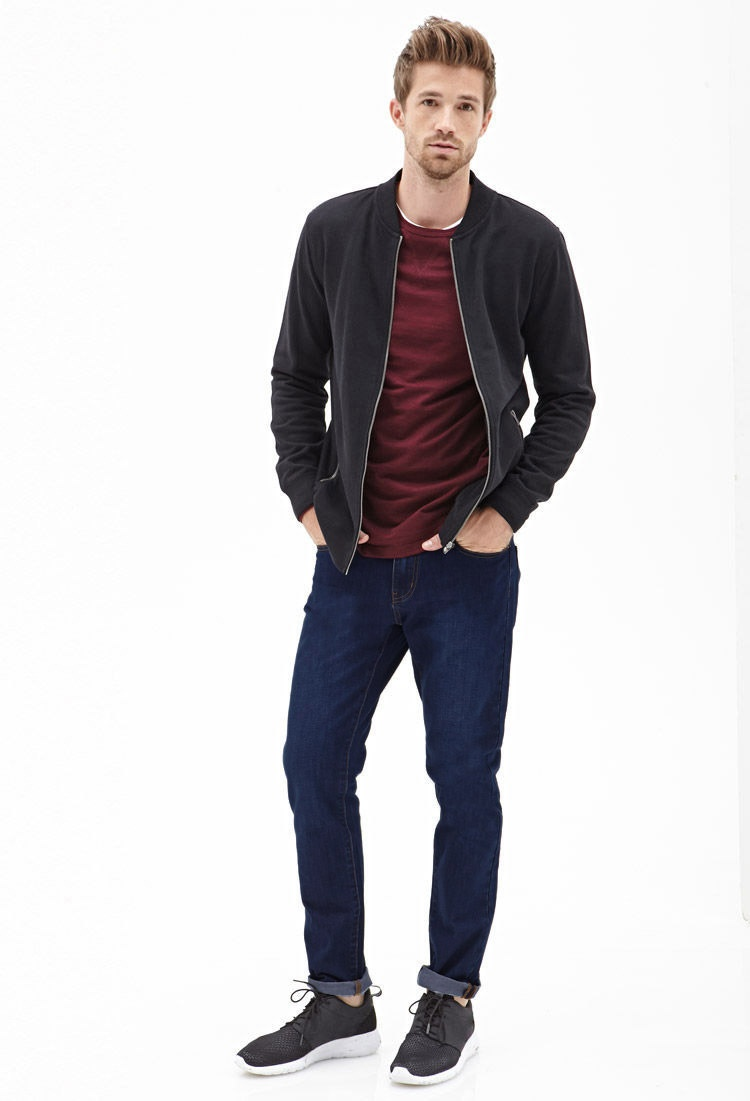

array([[[0.99215686, 0.99215686, 0.99215686],
        [0.99215686, 0.99215686, 0.99215686],
        [0.99215686, 0.99215686, 0.99215686],
        ...,
        [0.972549  , 0.972549  , 0.972549  ],
        [0.972549  , 0.972549  , 0.972549  ],
        [0.972549  , 0.972549  , 0.972549  ]],

       [[0.99215686, 0.99215686, 0.99215686],
        [0.99215686, 0.99215686, 0.99215686],
        [0.99215686, 0.99215686, 0.99215686],
        ...,
        [0.972549  , 0.972549  , 0.972549  ],
        [0.972549  , 0.972549  , 0.972549  ],
        [0.972549  , 0.972549  , 0.972549  ]],

       [[0.99215686, 0.99215686, 0.99215686],
        [0.99215686, 0.99215686, 0.99215686],
        [0.99215686, 0.99215686, 0.99215686],
        ...,
        [0.972549  , 0.972549  , 0.972549  ],
        [0.972549  , 0.972549  , 0.972549  ],
        [0.972549  , 0.972549  , 0.972549  ]],

       ...,

       [[0.99607843, 0.99607843, 0.99607843],
        [0.99607843, 0.99607843, 0.99607843],
        [0.99607843, 0

,0
image_path,MEN-Denim-id_00000750-01_1_front.jpg
caption,"His sweater has long sleeves, cotton fabric an..."


In [4]:
from torchvision import transforms
train_transform=transforms.Compose([transforms.Resize(512,interpolation=transforms.InterpolationMode.BICUBIC),transforms.RandomCrop((512,512)),transforms.RandomHorizontalFlip(),transforms.ToTensor(),transforms.Normalize([.5]*3,[.5]*3)])
validation_transform=transforms.Compose([transforms.Resize(512,interpolation=transforms.InterpolationMode.BICUBIC),transforms.CenterCrop((512,512)),transforms.ToTensor(),transforms.Normalize([.5]*3,[.5]*3)])
with Image.open(IMAGES_DIR/manifest.iloc[0].image_path) as source_image:
    original=source_image.convert("RGB")
transformed=train_transform(original)
transformed_unnormalized=(transformed*0.5+0.5).clamp(0,1)
print("actual transformed tensor:",tuple(transformed.shape),transformed.dtype)
display(original); display(transformed_unnormalized.permute(1,2,0).numpy()); display(manifest.iloc[0][["image_path","caption"]].to_frame())



## Write exact manifests and summary JSON

In [5]:
INTERIM_DIR.mkdir(parents=True,exist_ok=True)
columns=["image_path","caption","split","width","height","mode","aspect_ratio","caption_hash"]
train_paths=set(manifest.loc[manifest.split=="train","image_path"]); validation_paths=set(manifest.loc[manifest.split=="validation","image_path"])
assert train_paths.isdisjoint(validation_paths), "Train/validation image leakage detected"
manifest[columns].to_csv(MANIFEST_PATH,index=False); manifest.loc[manifest.split=="train",columns].to_csv(TRAIN_CSV_PATH,index=False); manifest.loc[manifest.split=="validation",columns].to_csv(VALIDATION_CSV_PATH,index=False)
summary={"caption_records":int(len(records)),"matched_records":int(len(manifest)),"empty_caption_records_removed":int(full_dataset_empty),"empty_caption_records_removed_in_sample":int(empty_caption_in_sample),"full_dataset_unmatched_caption_records":int(full_dataset_unmatched_caption_records),"sample_images_without_caption":int(sample_images_without_caption),"sample_records_selected_for_processing":int(sample_records_selected_for_processing),"invalid_images":int(len(corrupt)),"duplicate_records_removed":int(duplicate_records_removed),"duplicate_caption_records_removed":int(duplicate_caption_records),"rows_in_duplicate_caption_groups":int(manifest.caption_hash.duplicated(keep=False).sum()),"train_count":int((manifest.split=="train").sum()),"validation_count":int((manifest.split=="validation").sum()),"fast_dev_run":bool(FAST_DEV_RUN)}
SUMMARY_JSON_PATH.write_text(json.dumps(summary,indent=2),encoding="utf-8"); print(summary)


{'caption_records': 42544, 'matched_records': 970, 'empty_caption_records_removed': 7, 'empty_caption_records_removed_in_sample': 1, 'full_dataset_unmatched_caption_records': 0, 'sample_images_without_caption': 30, 'sample_records_selected_for_processing': 1000, 'invalid_images': 0, 'duplicate_records_removed': 0, 'duplicate_caption_records_removed': 0, 'rows_in_duplicate_caption_groups': 6, 'train_count': 873, 'validation_count': 97, 'fast_dev_run': True}



## Restart validation and limitations

In [6]:
for path in [MANIFEST_PATH,TRAIN_CSV_PATH,VALIDATION_CSV_PATH,SUMMARY_JSON_PATH]: assert path.exists(),path
for path in [MANIFEST_PATH,TRAIN_CSV_PATH,VALIDATION_CSV_PATH]: assert list(pd.read_csv(path).columns)==columns
print("Derived files validated:",MANIFEST_PATH,TRAIN_CSV_PATH,VALIDATION_CSV_PATH)

Derived files validated: d:\Deep Learning\Project\GITHUB\Explainable-Fashion-Design-AI\data\interim\deepfashion_generation_manifest.csv d:\Deep Learning\Project\GITHUB\Explainable-Fashion-Design-AI\data\interim\deepfashion_generation_train.csv d:\Deep Learning\Project\GITHUB\Explainable-Fashion-Design-AI\data\interim\deepfashion_generation_validation.csv



Preprocessing cannot repair missing/ambiguous captions or corrupted images. Resize+center-crop preserves orientation but crops extreme aspect ratios; inspect the preview before training.